¡Te han pedido que apoyes a un equipo de investigación que ha estado recopilando datos sobre pingüinos en la Antártida! Los datos están disponibles en formato CSV como `penguins.csv`.

**Origen de estos datos**: Los datos fueron recopilados y puestos a disposición por la Dra. Kristen Gorman y la Palmer Station, Antarctica LTER, miembro de la Long Term Ecological Research Network.

**El conjunto de datos consta de 5 columnas.**

Columna | Descripción
--- | ---
culmen_length_mm | longitud del culmen (mm)
culmen_depth_mm | profundidad del culmen (mm)
flipper_length_mm | longitud de la aleta (mm)
body_mass_g | masa corporal (g)
sex | sexo del pingüino

Lamentablemente, no han podido registrar la especie de cada pingüino, pero saben que hay **al menos tres** especies nativas de la región: **Adelie**, **Chinstrap** y **Gentoo**. Tu tarea es aplicar tus habilidades de ciencia de datos para ayudarles a identificar grupos en el conjunto de datos.

In [19]:
# Importar las librerias requeridas
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Cargar y analizar el Dataset
penguins_df = pd.read_csv("penguins.csv")
penguins_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE


In [20]:
# Verificar tipos de datos y valores nulos
print(penguins_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   332 non-null    float64
 1   culmen_depth_mm    332 non-null    float64
 2   flipper_length_mm  332 non-null    float64
 3   body_mass_g        332 non-null    float64
 4   sex                332 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.1+ KB
None


In [21]:
# verificamos valores faltantes
print(penguins_df.isna().sum())



culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [22]:
# Revisamos caracteristicas descriptivas de las variables númericas 
print(penguins_df.describe())

       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
count        332.000000       332.000000         332.000000   332.000000
mean          44.021084        17.153012         200.975904  4206.475904
std            5.452462         1.960275          14.035971   806.361278
min           32.100000        13.100000         172.000000  2700.000000
25%           39.500000        15.600000         190.000000  3550.000000
50%           44.700000        17.300000         197.000000  4025.000000
75%           48.625000        18.700000         213.000000  4781.250000
max           59.600000        21.500000         231.000000  6300.000000


In [23]:
# Convertimos la variable categórica 'sex' en variables númericas
penguins_dummies = pd.get_dummies(penguins_df, drop_first = True)
print(penguins_dummies.head())

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  sex_MALE
0              39.1             18.7              181.0       3750.0         1
1              39.5             17.4              186.0       3800.0         0
2              40.3             18.0              195.0       3250.0         0
3              36.7             19.3              193.0       3450.0         0
4              39.3             20.6              190.0       3650.0         1


In [ ]:
# Escalamos los datos. Creamos el escalador 
scaler = StandardScaler()

# Transformar los datos escalados a una matriz númerica 
penguins_scaled = scaler.fit_transform(penguins_dummies)

# Convertir de nuevo a DataFrame para mantener los nombres de las columnas 
penguins_scaled = pd.DataFrame(penguins_scaled, columns = penguins_dummies.columns)

# Inspeccionar las primeras filas con datos escalados 
print(penguins_scaled.head())

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  sex_MALE
0         -0.903906         0.790360          -1.425342    -0.566948  0.993994
1         -0.830434         0.126187          -1.068577    -0.504847 -1.006042
2         -0.683490         0.432728          -0.426399    -1.187953 -1.006042
3         -1.344738         1.096901          -0.569105    -0.939551 -1.006042
4         -0.867170         1.761074          -0.783164    -0.691149  0.993994


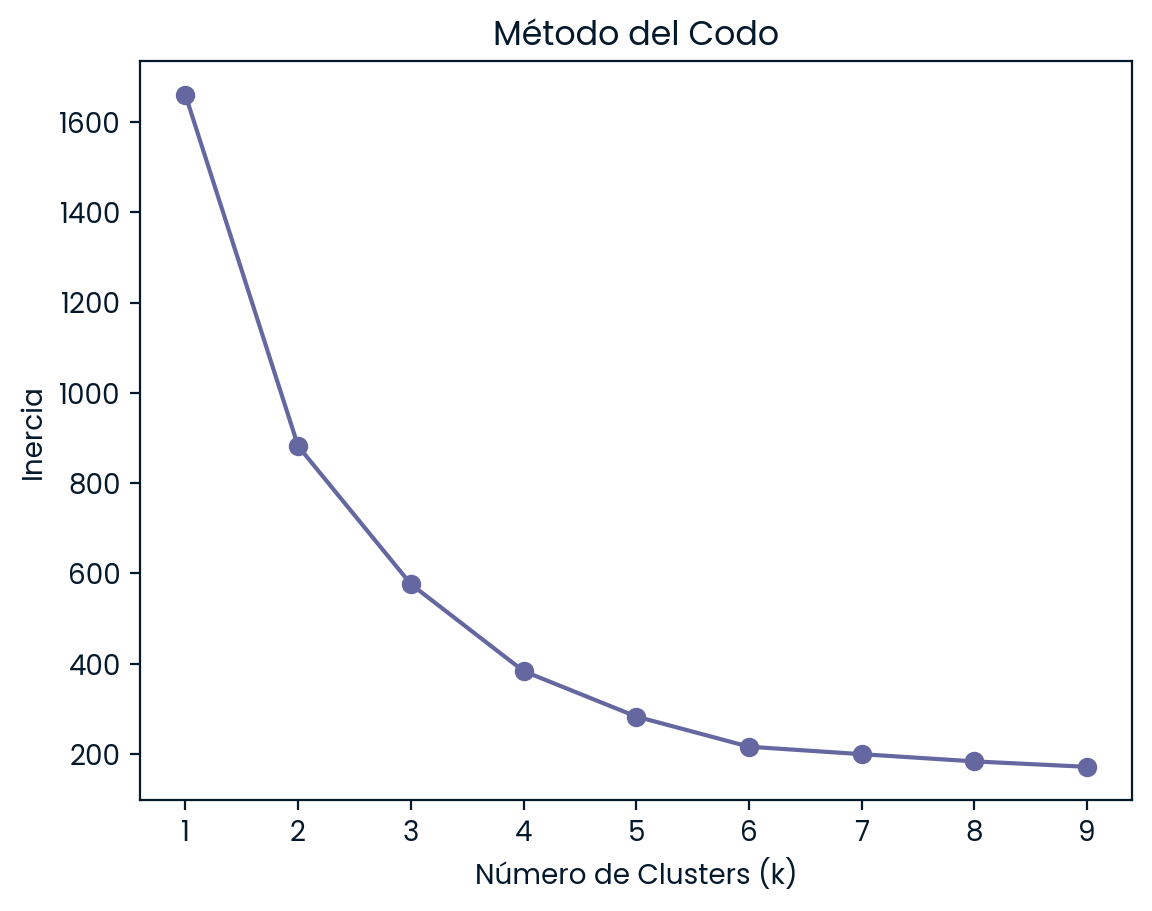

In [25]:
# Lista para almacenar los valores de inercia
inertia = []

# Probar k desde 1 hasta 10 
for k in range(1,10):
    kmeans = KMeans(n_clusters= k, random_state = 42)
    kmeans.fit(penguins_scaled)
    inertia.append(kmeans.inertia_)

# Grficar el método del codo
plt.plot(range(1,10), inertia, marker = 'o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

In [26]:
# Crear y entrenar el modelo K-Means con k = 4
kmeans = KMeans(n_clusters = 4, random_state = 42)
penguins_dummies['label'] = kmeans.fit_predict(penguins_scaled)

# Asignar las etiquetas al DataFrame original (para calcular los promedios reales)
penguins_df['label'] = penguins_dummies['label']

# Verificar las primeras filas 
print(penguins_df.head())

   culmen_length_mm  culmen_depth_mm  ...     sex  label
0              39.1             18.7  ...    MALE      0
1              39.5             17.4  ...  FEMALE      2
2              40.3             18.0  ...  FEMALE      2
3              36.7             19.3  ...  FEMALE      2
4              39.3             20.6  ...    MALE      0

[5 rows x 6 columns]


In [27]:
# Seleccionar solo las columnas numéricas junto con la etiqueta
numeric_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'label']

# Calcular los promedios por cluster
stat_penguins = penguins_df[numeric_cols].groupby('label').mean()

print(stat_penguins)

       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
label                                                                   
0             43.878302        19.111321         194.764151  4006.603774
1             45.563793        14.237931         212.706897  4679.741379
2             40.217757        17.611215         189.046729  3419.158879
3             49.473770        15.718033         221.540984  5484.836066


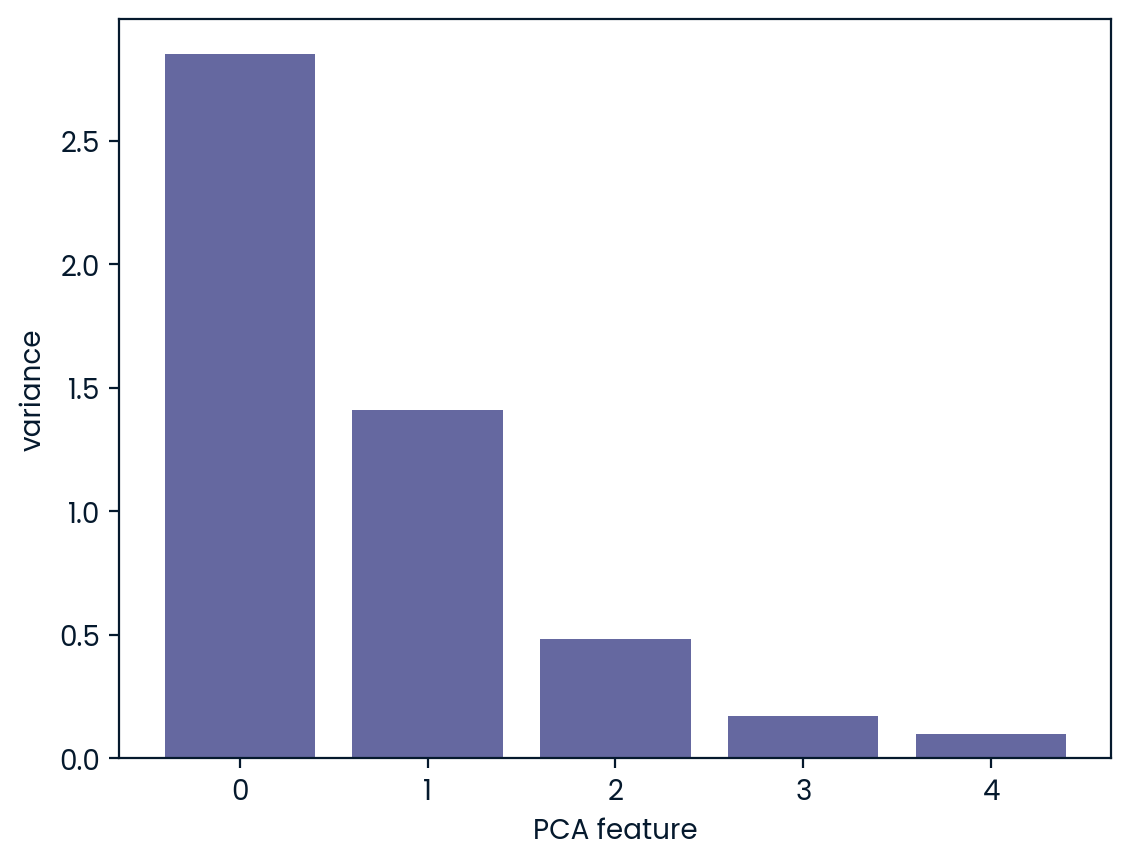

In [33]:
from sklearn.decomposition import PCA

# Crear el objeto PCA 
pca = PCA()

# Transformar los datos escalados
pca.fit(penguins_scaled)

# Plot the explained variances
features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_)
plt.xlabel('PCA feature')
plt.ylabel('variance')
plt.xticks(features)
plt.show()



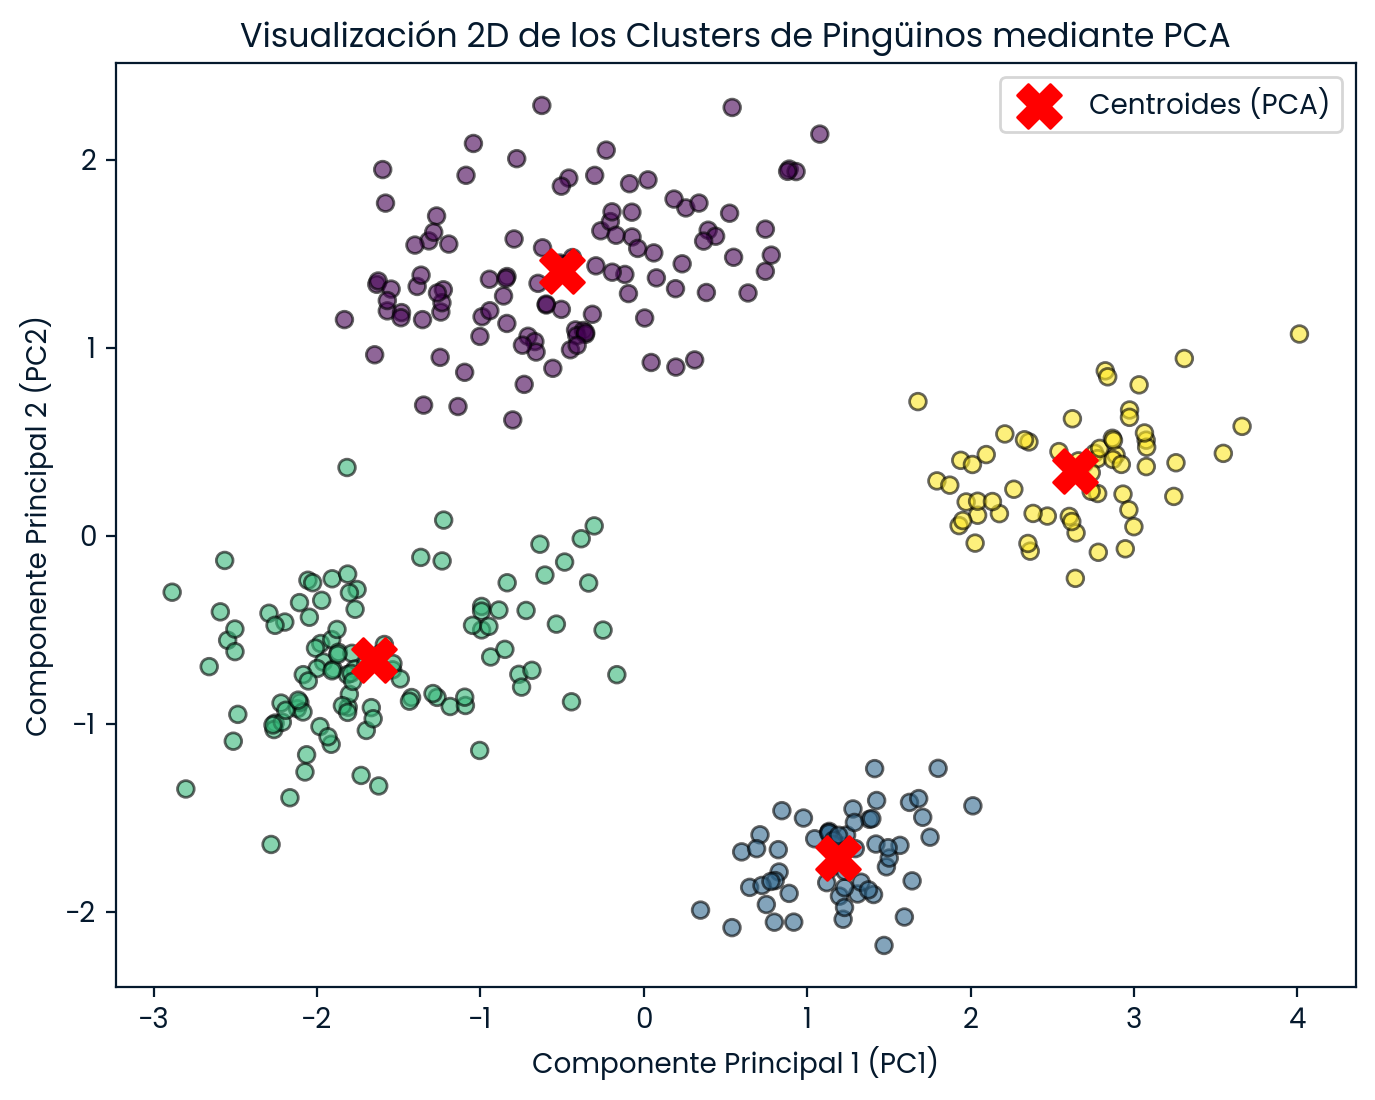

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Crear el objeto PCA para reducir a 2 componentes
pca = PCA(n_components=2)

# Transformar los datos escalados (las 4+1 dimensiones) a 2D
penguins_pca = pca.fit_transform(penguins_scaled)

# Obtener las coordenadas 2D de los centroides con PCA
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Crear la gráfica 2D con las dos componentes principales
plt.figure(figsize=(8, 6))
plt.scatter(
    penguins_pca[:, 0], 
    penguins_pca[:, 1], 
    c=penguins_df['label'], 
    cmap='viridis', 
    alpha=0.6,
    edgecolors='k'
)

# Dibujar los centroides comprimidos (las "X" rojas)
plt.scatter(
    centroids_pca[:, 0], 
    centroids_pca[:, 1], 
    s=250, 
    c='red', 
    marker='X', 
    label='Centroides (PCA)'
)

plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.title('Visualización 2D de los Clusters de Pingüinos mediante PCA')
plt.legend()
plt.show()
